# Посимвольная токенизация

Обучение и сравнение пяти генеративных моделей (Simple RNN, LSTM 1-слойная, LSTM 3-слойная, двунаправленная LSTM, MiniGPT) с использованием **посимвольной токенизации** на датасете Medium Articles.

In [2]:
import torch
import os
import sys

# Ensure project root is on path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '.')) if os.path.exists('utils.py') else os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils import load_medium_articles, TextDataset, make_dataloaders, train_model, compute_perplexity, generate_text, plot_training_curves, print_generation_samples
from models import build_all_models, count_parameters

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')

Устройство: cuda
GPU: NVIDIA GeForce RTX 4060 Ti

## 1. Загрузка датасета

In [3]:
corpus = load_medium_articles('data/medium_articles.csv', max_articles=5000)
print(f'Пример: {corpus[:300]}')

Загружено 5000 статей, длина корпуса: 28,081,679 символов
Пример: Photo by Josh Riemer on Unsplash

Merry Christmas and Happy Holidays, everyone!

We just wanted everyone to know how much we appreciate everyone and how thankful we are for all our readers and writers here. We wouldn't be anywhere without you, so thank you all for bringing informative, vulnerable, a

## 2. Посимвольный токенизатор

In [4]:
class CharTokenizer:
    """Посимвольный токенизатор."""

    def __init__(self, corpus):
        chars = sorted(set(corpus))
        self.char2idx = {c: i for i, c in enumerate(chars)}
        self.idx2char = {i: c for c, i in self.char2idx.items()}
        self.vocab_size = len(chars)

    def encode(self, text):
        return [self.char2idx[c] for c in text if c in self.char2idx]

    def decode(self, ids):
        return ''.join(self.idx2char.get(i, '?') for i in ids)


tokenizer = CharTokenizer(corpus)
print(f'Размер словаря: {tokenizer.vocab_size}')
print(f'Символы: {list(tokenizer.char2idx.keys())[:50]} ...')

Размер словаря: 2774
Символы: ['\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P'] ...

In [5]:
# Кодирование корпуса
token_ids = tokenizer.encode(corpus)
print(f'Всего токенов: {len(token_ids):,}')
print(f'Первые 50 id: {token_ids[:50]}')
print(f'Декодировано обратно: {tokenizer.decode(token_ids[:50])}')

Всего токенов: 28,081,679
Первые 50 id: [49, 73, 80, 85, 80, 1, 67, 90, 1, 43, 80, 84, 73, 1, 51, 74, 70, 78, 70, 83, 1, 80, 79, 1, 54, 79, 84, 81, 77, 66, 84, 73, 0, 0, 46, 70, 83, 83, 90, 1, 36, 73, 83, 74, 84, 85, 78, 66, 84, 1]
Декодировано обратно: Photo by Josh Riemer on Unsplash

Merry Christmas

## 3. Создание DataLoader'ов

In [6]:
SEQ_LEN = 128
BATCH_SIZE = 512

train_dl, val_dl = make_dataloaders(token_ids, SEQ_LEN, BATCH_SIZE, val_split=0.1)
print(f'Батчей на эпоху — train: {len(train_dl)}, val: {len(val_dl)}')

Последовательностей — train: 197449, val: 21938
Батчей на эпоху — train: 385, val: 42

## 4. Построение моделей

In [7]:
EMBED_DIM = 128
HIDDEN_DIM = 256
GPT_DIM = 256
GPT_HEADS = 4
GPT_LAYERS = 4
GPT_FF = 512

models = build_all_models(
    vocab_size=tokenizer.vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    gpt_dim=GPT_DIM,
    gpt_heads=GPT_HEADS,
    gpt_layers=GPT_LAYERS,
    gpt_ff=GPT_FF,
    max_seq_len=SEQ_LEN,
)

for name, model in models.items():
    print(f'{name}: {count_parameters(model):,} параметров')

SimpleRNN: 1,166,806 параметров
LSTM_1layer: 1,463,254 параметров
LSTM_3layer: 2,515,926 параметров
BiLSTM: 4,145,622 параметров
MiniGPT: 2,851,840 параметров

## 4б. Загрузка сохранённых чекпойнтов (пропуск обучения)

In [8]:
# Загрузка чекпойнтов вместо повторного обучения.
# Ячейки 1-4 выше должны быть выполнены (токенизатор + модели).

import glob

SAVE_DIR = 'checkpoints/char'
loaded = []
for name, model in models.items():
    ckpt = os.path.join(SAVE_DIR, f'char_{name}_best.pt')
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        loaded.append(name)
        print(f'Загружена {name} из {ckpt}')
    else:
        print(f'ВНИМАНИЕ: чекпойнт не найден для {name} по пути {ckpt}')

print(f'\nЗагружено моделей: {len(loaded)}/{len(models)}')

Загружена SimpleRNN из checkpoints/char/char_SimpleRNN_best.pt
Загружена LSTM_1layer из checkpoints/char/char_LSTM_1layer_best.pt
Загружена LSTM_3layer из checkpoints/char/char_LSTM_3layer_best.pt
Загружена BiLSTM из checkpoints/char/char_BiLSTM_best.pt
Загружена MiniGPT из checkpoints/char/char_MiniGPT_best.pt

Загружено моделей: 5/5

## 5. Обучение всех моделей

In [15]:
EPOCHS = 15
PATIENCE = 5
SAVE_DIR = 'checkpoints/char'

histories = {}

training_config = {
    'SimpleRNN':   {'lr': 1e-3, 'use_amp': False},
    'LSTM_1layer': {'lr': 1e-3, 'use_amp': False},
    'LSTM_3layer': {'lr': 1e-3, 'use_amp': False},
    'BiLSTM':      {'lr': 1e-3, 'use_amp': False},
    'MiniGPT':     {'lr': 3e-4, 'use_amp': True},
}

In [16]:
for name, model in models.items():
    print(f'\nОбучение {name}')
    print('-' * 40)
    cfg = training_config[name]
    histories[name] = train_model(
        model, train_dl, val_dl,
        epochs=EPOCHS,
        lr=cfg['lr'],
        device=DEVICE,
        use_amp=cfg['use_amp'],
        patience=PATIENCE,
        model_name=f'char_{name}',
        save_dir=SAVE_DIR,
    )

Обучение SimpleRNN
----------------------------------------
  [char_SimpleRNN] Epoch 1: train_loss=2.5042  val_loss=2.0472  val_ppl=7.75
  [char_SimpleRNN] Epoch 2: train_loss=1.9595  val_loss=1.8331  val_ppl=6.25
  [char_SimpleRNN] Epoch 3: train_loss=1.8340  val_loss=1.7390  val_ppl=5.69
  [char_SimpleRNN] Epoch 4: train_loss=1.7726  val_loss=1.6888  val_ppl=5.41
  [char_SimpleRNN] Epoch 5: train_loss=1.7384  val_loss=1.6606  val_ppl=5.26
  [char_SimpleRNN] Epoch 6: train_loss=1.7139  val_loss=1.6393  val_ppl=5.15
  [char_SimpleRNN] Epoch 7: train_loss=1.6965  val_loss=1.6230  val_ppl=5.07
  [char_SimpleRNN] Epoch 8: train_loss=1.6848  val_loss=1.6120  val_ppl=5.01
  [char_SimpleRNN] Epoch 9: train_loss=1.6738  val_loss=1.6033  val_ppl=4.97
  [char_SimpleRNN] Epoch 10: train_loss=1.6662  val_loss=1.5963  val_ppl=4.93
  [char_SimpleRNN] Epoch 11: train_loss=1.6631  val_loss=1.5952  val_ppl=4.93
  [char_SimpleRNN] Epoch 12: train_loss=1.6555  val_loss=1.5891  val_ppl=4.90
  [char_Simpl

## 6. Кривые обучения

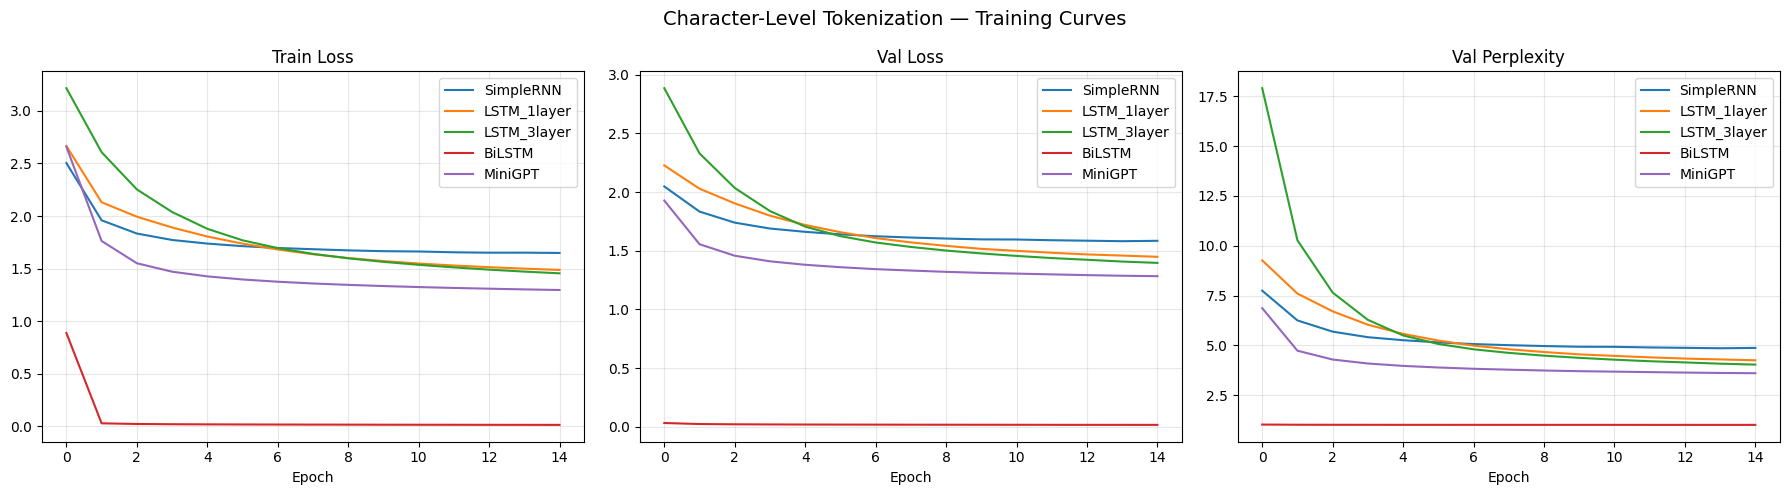

In [17]:
plot_training_curves(histories, title='Character-Level Tokenization — Training Curves')

## 7. Итоговое сравнение перплексии

In [18]:
print(f'{"Модель":<20} {"Перплексия":<15} {"Параметры":<15}')
print('-' * 50)
for name, model in models.items():
    ppl = compute_perplexity(model, val_dl, device=DEVICE, use_amp=('GPT' in name))
    params = count_parameters(model)
    print(f'{name:<20} {ppl:<15.2f} {params:<15,}')

Модель               Перплексия      Параметры
--------------------------------------------------
SimpleRNN            4.86            1,166,806
LSTM_1layer          4.25            1,463,254
LSTM_3layer          4.04            2,515,926
BiLSTM               1.02            4,145,622
MiniGPT              3.61            2,851,840

## 8. Примеры генерации текста

In [9]:
seed_text = 'The future of artificial intelligence '
seed_ids = tokenizer.encode(seed_text)
print(f'Сид: "{seed_text}"')
print(f'Количество токенов: {len(seed_ids)}')

Сид: "The future of artificial intelligence "
Количество токенов: 38

In [10]:
samples = {}
for name, model in models.items():
    samples[name] = generate_text(
        model, seed_ids, tokenizer.decode,
        length=300, temperature=0.8, top_k=0,
        device=DEVICE, max_context=SEQ_LEN,
    )

print_generation_samples(samples, title='Примеры генерации (посимвольная токенизация)')

Примеры генерации (посимвольная токенизация)

--- SimpleRNN ---
The future of artificial intelligence on the important one for business is a sense what I for the matcing balif. It I aren't a science provide going has been interesting the manager and the information a spewn as the silows with 10–100 Data

The following compatis andident the systems. The yeart file was all the audles application of th

--- LSTM_1layer ---
The future of artificial intelligence and designers like markething on Jesks something reliethor errors at the day mission it to preferral life in evilarity of the best to uter's an enjoyed company that grow the puscapter projects and deep in 20 sides who will also be a good symbols to you offered around when you, can be able to mean th

--- LSTM_3layer ---
The future of artificial intelligence which is also never second realized or your real solutions for our clothes. The source of a greatly interesting history. And that don't have to read me around from a conscious of

## 9. Генерация при различных температурах

In [11]:
# Влияние температуры на лучшую модель (MiniGPT)
best_model = models['MiniGPT']
for temp in [0.3, 0.5, 0.8, 1.0, 1.2]:
    text = generate_text(
        best_model, seed_ids, tokenizer.decode,
        length=200, temperature=temp, top_k=0,
        device=DEVICE, max_context=SEQ_LEN,
    )
    print(f'\n--- Температура = {temp} ---')
    print(text[:300])

--- Температура = 0.3 ---
The future of artificial intelligence between the model and the first time is the first time to access the first time.

As a simple as a matrix of the internet processes in the case of the world. The program was a series of the problems w

--- Температура = 0.5 ---
The future of artificial intelligence is pretty more than the company of the two simplest options and a container that is the most product of the training responses to the output of our strengths to a high quality from our service.

As we

--- Температура = 0.8 ---
The future of artificial intelligence between 10 to 100 and 60% of users and square are of this.

The data correctly for a single brand button for a local traffic command: we must have to use the performance of the platform and horrible f

--- Температура = 1.0 ---
The future of artificial intelligence is repeatedly producted to the experience."

One side, it is represented the survivor of that far delicious and definitely profile to enab

## 10. Итоги

| Модель | Val Loss | Val Perplexity | Параметры |
|--------|----------|----------------|-----------|
| SimpleRNN | 1.5808 | 4.86 | 1 166 806 |
| LSTM (1 слой) | 1.4479 | 4.25 | 1 463 254 |
| LSTM (3 слоя) | 1.3960 | 4.04 | 2 515 926 |
| Bidirectional LSTM | 0.0155 | 1.02 | 4 145 622 |
| MiniGPT | 1.2828 | 3.61 | 2 851 840 |

**Лучшая модель по перплексии:** MiniGPT (3.61) — среди однонаправленных моделей, пригодных для генерации.

> **Примечание:** BiLSTM показывает аномально низкую перплексию (~1.02), так как двунаправленная архитектура «видит» будущие токены при вычислении loss. Это делает её непригодной для авторегрессионной генерации, но формально она минимизирует loss лучше всех.